# **Análisis de Activos Financieros por Industria**
## **Actividad 1: Visualización Efectiva de Datos**

---

### **Información Académica**
* **Institución:** Universidad Tecmilenio
* **Programa:** Maestría en Gestión de las Tecnologías de la Información
* **Materia:** Visualización Efectiva de Datos
* **Autor:** Joseph González
* **Fecha:** Mayo 2026

---

### **Ficha Técnica del Proyecto**

> **Objetivo:** > Identificar el activo (*asset*) con mejor comportamiento histórico por industria para optimizar la selección y ponderación del *watchlist* estructural en un sistema de trading asistido por Inteligencia Artificial (IA).

* **Período de Análisis:** Mayo 2025 – Mayo 2026
* **Universo de Estudio:** 14 activos financieros distribuidos en 5 industrias estratégicas.
* **Fuente de Datos:** Yahoo Finance vía API de `yfinance` (Infraestructura de Alpaca Markets).
* **Ecosistema Tecnológico:** Python, `pandas`, `numpy`, `matplotlib` y `seaborn`.

---

## 1. Configuración

In [26]:
# Instalación
!pip install yfinance --quiet

# Importaciones
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo global de gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Librerías listas")

✅ Librerías listas


## 2. Definición del Universo de Assets

In [27]:
# Universo de assets por industria
industrias = {
    "Tecnología":      ["QQQ", "NVDA", "AAPL", "MSFT"],
    "Mercado Amplio":  ["SPY", "VTI", "IWM"],
    "Commodities":     ["GLD", "SLV", "USO"],
    "Crypto":          ["BTC-USD", "ETH-USD"],
    "Salud":           ["XLV", "JNJ", "PFE"]
}

# Lista plana de todos los tickers
todos_los_assets = [asset for grupo in industrias.values() for asset in grupo]

print("📊 Industrias y assets definidos:")
for industria, assets in industrias.items():
    print(f"  {industria}: {', '.join(assets)}")

print(f"\n✅ Total: {len(todos_los_assets)} assets en {len(industrias)} industrias")

📊 Industrias y assets definidos:
  Tecnología: QQQ, NVDA, AAPL, MSFT
  Mercado Amplio: SPY, VTI, IWM
  Commodities: GLD, SLV, USO
  Crypto: BTC-USD, ETH-USD
  Salud: XLV, JNJ, PFE

✅ Total: 15 assets en 5 industrias


## 3. Descarga de Datos

In [28]:
# Período de análisis: 1 año
inicio = "2025-05-01"
fin = "2026-05-01"

# Descargar precios de cierre de todos los assets
print("⏳ Descargando datos...")

precios = yf.download(
    todos_los_assets,
    start=inicio,
    end=fin,
    auto_adjust=True
)["Close"]

# Verificar descarga
print(f"\n✅ Datos descargados: {precios.shape[0]} días x {precios.shape[1]} assets")
print(f"📅 Período: {precios.index[0].date()} → {precios.index[-1].date()}")
print(f"\n🔍 Primeras filas:")
precios.head(10)

[**********            20%                       ]  3 of 15 completed

⏳ Descargando datos...


[*********************100%***********************]  15 of 15 completed



✅ Datos descargados: 365 días x 15 assets
📅 Período: 2025-05-01 → 2026-04-30

🔍 Primeras filas:


Ticker,AAPL,BTC-USD,ETH-USD,GLD,IWM,JNJ,MSFT,NVDA,PFE,QQQ,SLV,SPY,USO,VTI,XLV
Date,,,,,,,,,,,,,,,
2025-05-01,212.198807,96492.335938,1839.221558,297.459991,193.979584,149.413834,421.255646,111.583702,21.948259,479.359680,29.389999,552.140442,64.519997,271.312927,134.245819
2025-05-02,204.270691,96910.070312,1842.707886,297.980011,198.342575,151.019577,431.039429,114.473030,22.195900,486.475220,29.120001,560.336609,64.010002,275.542969,136.102707
2025-05-03,NaN,95891.796875,1833.839722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-04,NaN,94315.976562,1808.594238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-05,197.844635,94748.054688,1819.697510,306.880005,196.818985,149.936172,431.920776,113.793190,21.893227,483.589203,29.480000,557.123352,62.369999,273.981415,135.719528
2025-05-06,197.466629,96802.476562,1815.087524,315.480011,194.672119,149.423492,429.088593,113.513260,20.985210,479.091003,30.219999,552.466736,64.599998,271.757660,131.976288
2025-05-07,195.218506,97032.320312,1811.606689,310.750000,195.315201,152.161041,429.128235,117.032425,20.902668,480.971893,29.490000,554.790161,63.509998,272.884369,132.988251
2025-05-08,196.451996,103241.460938,2206.514648,304.630005,199.035110,150.574615,433.901245,117.342361,21.067760,485.937866,29.459999,558.655762,65.599998,275.029022,131.789627
2025-05-09,197.486526,102970.851562,2345.507324,306.839996,198.669052,149.181656,434.455811,116.622520,20.824741,485.619415,29.799999,557.944031,66.610001,274.722626,130.355194


## 4. Construcción de Variables
### 4.1 Descripción del Dataset

## Descripción del Dataset

**Fuente:** Yahoo Finance via yfinance  
**Período:** Mayo 2025 – Mayo 2026  
**Días de trading:** 251  
**Assets analizados:** 15 en 5 industrias  

| Variable | Tipo | Descripción | Ejemplo |
|---|---|---|---|
| `asset` | Nominal | Nombre del instrumento financiero | BTC-USD, NVDA, GLD |
| `tendencia` | Ordinal | Dirección del mercado en el período | Bajista / Lateral / Alcista |
| `dias_señal` | Discreta | Días donde el precio tuvo movimiento extremo | 3, 7, 12 días |
| `retorno_diario` | Continua | Variación porcentual del precio día a día | +2.3%, -0.87% |

**Variable dependiente principal:** `retorno_diario` — base del análisis comparativo entre industrias.

### 4.2 Limpieza y cálculo de variables

In [29]:
# Eliminar filas con NaN (fines de semana y festivos)
precios_limpios = precios.dropna()

# Calcular retorno diario porcentual
retornos_diarios = precios_limpios.pct_change().dropna() * 100

# Calcular retorno total del período por asset
retorno_total = ((precios_limpios.iloc[-1] - precios_limpios.iloc[0]) / precios_limpios.iloc[0] * 100).round(2)

print("✅ Datos limpios")
print(f"📅 Días de trading: {len(precios_limpios)}")
print(f"\n📈 Retorno total por asset (%):")
print(retorno_total.sort_values(ascending=False).to_string())

✅ Datos limpios
📅 Días de trading: 251

📈 Retorno total por asset (%):
Ticker
USO        127.98
SLV        126.81
NVDA        78.85
JNJ         52.95
IWM         43.30
GLD         42.43
QQQ         39.30
VTI         30.54
SPY         30.16
AAPL        27.76
ETH-USD     22.67
PFE         19.67
XLV          8.75
MSFT        -3.41
BTC-USD    -20.92


In [30]:
print("\n🔍 Muestra de retornos diarios (primeras 5 filas):")
retornos_diarios.head()


🔍 Muestra de retornos diarios (primeras 5 filas):


Ticker,AAPL,BTC-USD,ETH-USD,GLD,IWM,JNJ,MSFT,NVDA,PFE,QQQ,SLV,SPY,USO,VTI,XLV
Date,,,,,,,,,,,,,,,
2025-05-02,-3.736174,0.432920,0.189555,0.174820,2.249201,1.074695,2.322529,2.589382,1.128293,1.484384,-0.918675,1.484435,-0.790444,1.559101,1.383200
2025-05-05,-3.145853,-2.230950,-1.248726,2.986775,-0.768161,-0.717393,0.204470,-0.593887,-1.363645,-0.593251,1.236259,-0.573451,-2.562105,-0.566719,-0.281536
2025-05-06,-0.191062,2.168300,-0.253338,2.802400,-1.090782,-0.341932,-0.655718,-0.245999,-4.147475,-0.930170,2.510176,-0.835832,3.575436,-0.811644,-2.758071
2025-05-07,-1.138483,0.237436,-0.191772,-1.499306,0.330341,1.832074,0.009239,3.100224,-0.393336,0.392596,-2.415617,0.420555,-1.687307,0.414601,0.766776
2025-05-08,0.631851,6.399044,21.798769,-1.969427,1.904567,-1.042597,1.112257,0.264830,0.789815,1.032487,-0.101732,0.696768,3.290821,0.785920,-0.901300


### 4.3 Tendencia y días con señal

In [31]:
# ── Variable 3: Tendencia por asset (Ordinal) ──────────────────
# Calculada con EMA de 20 días
# Si precio actual > EMA20 → Alcista
# Si precio actual < EMA20 × 0.98 → Bajista
# Si no → Lateral

ema20 = precios_limpios.rolling(window=20).mean()
precio_final = precios_limpios.iloc[-1]
ema_final = ema20.iloc[-1]

tendencia = {}
for asset in precios_limpios.columns:
    if precio_final[asset] > ema_final[asset]:
        tendencia[asset] = "Alcista"
    elif precio_final[asset] < ema_final[asset] * 0.98:
        tendencia[asset] = "Bajista"
    else:
        tendencia[asset] = "Lateral"

df_tendencia = pd.Series(tendencia, name="Tendencia")

# ── Variable 4: Días con señal extrema por asset (Discreta) ────
# Días donde el retorno diario fue mayor a +3% o menor a -3%
dias_senal = (retornos_diarios.abs() > 3).sum()
dias_senal.name = "Dias_Senal"

# ── Resumen de las 4 variables ──────────────────────────────────
df_variables = pd.DataFrame({
    "Industria": [next(ind for ind, assets in industrias.items() if a in assets)
                  for a in precios_limpios.columns],
    "Tendencia": df_tendencia,
    "Dias_Senal": dias_senal,
    "Retorno_Total_%": retorno_total
})

print("✅ Las 4 variables calculadas:\n")
print(df_variables.sort_values("Retorno_Total_%", ascending=False).to_string())

✅ Las 4 variables calculadas:

              Industria Tendencia  Dias_Senal  Retorno_Total_%
USO         Commodities   Alcista          44           127.98
SLV         Commodities   Bajista          65           126.81
NVDA         Tecnología   Alcista          39            78.85
JNJ               Salud   Lateral           3            52.95
IWM      Mercado Amplio   Alcista           4            43.30
GLD         Commodities   Bajista          19            42.43
QQQ          Tecnología   Alcista           3            39.30
VTI      Mercado Amplio   Alcista           1            30.54
SPY      Mercado Amplio   Alcista           1            30.16
AAPL         Tecnología   Alcista          18            27.76
ETH-USD          Crypto   Lateral         110            22.67
PFE               Salud   Lateral          16            19.67
XLV               Salud   Lateral           2             8.75
MSFT         Tecnología   Alcista          11            -3.41
BTC-USD          Crypto 

## 5. Visualizaciones

### 5.1 Gráfica 1 — Retorno Total por Asset

### Justificación — Gráfica 1: Retorno Total por Asset

Se eligió una **gráfica de barras** porque la pregunta central es comparar
una variable continua (retorno total %) entre múltiples categorías nominales
(los 15 assets). Las barras permiten comparar magnitudes de forma inmediata
y sin ambigüedad visual.

Se aplicaron las siguientes buenas prácticas: el eje Y comienza en cero para
mantener una escala honesta, cada barra tiene el color de su industria para
codificar una segunda variable nominal sin agregar elementos extra, y las
etiquetas de valor encima de cada barra eliminan la necesidad de leer el eje
con precisión.

Los assets están ordenados de mayor a menor retorno, lo que permite identificar
de un vistazo los ganadores por industria. Esta gráfica responde directamente
la pregunta: *¿cuál asset tuvo mejor desempeño anual?*, siendo Commodities
la industria dominante con USO (+128%) y SLV (+127%) en los primeros lugares.

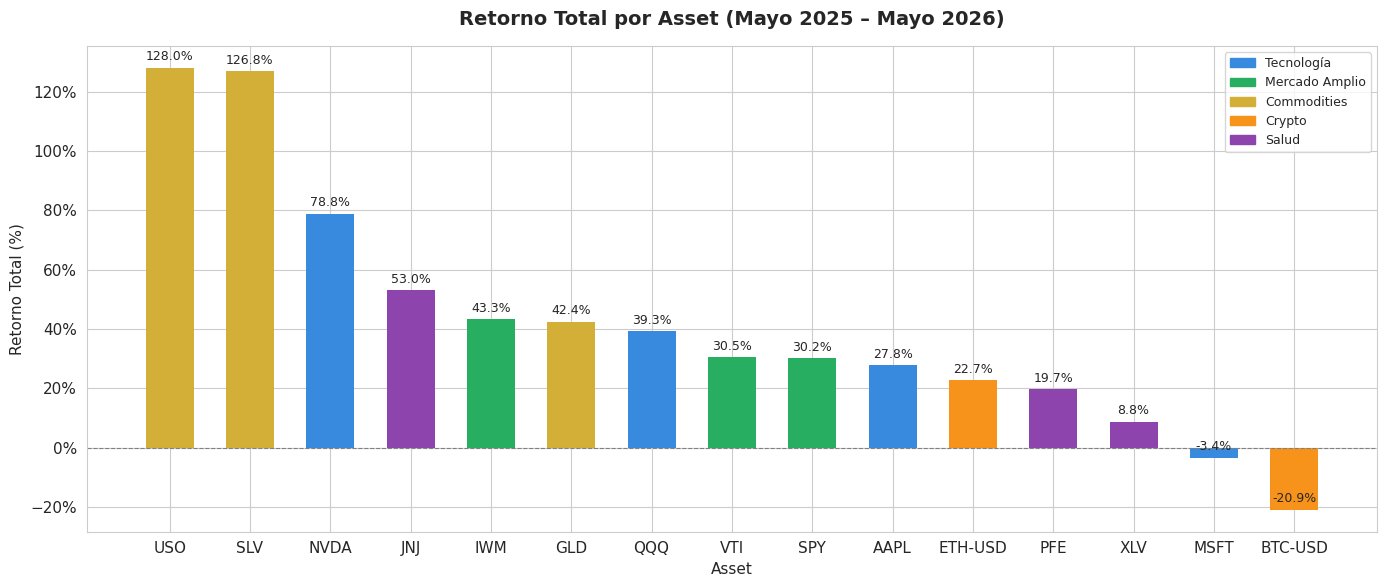

✅ Gráfica 1 guardada


In [32]:
# Colores por industria
colores_industria = {
    "Tecnología":     "#378ADD",
    "Mercado Amplio": "#27AE60",
    "Commodities":    "#D4AF37",
    "Crypto":         "#F7931A",
    "Salud":          "#8E44AD"
}

# Asignar color a cada asset según su industria
colores_barras = []
etiquetas_industria = []
for asset in retorno_total.sort_values(ascending=False).index:
    for industria, assets in industrias.items():
        if asset in assets:
            colores_barras.append(colores_industria[industria])
            etiquetas_industria.append(industria)
            break

# Graficar
fig, ax = plt.subplots(figsize=(14, 6))

barras = ax.bar(
    retorno_total.sort_values(ascending=False).index,
    retorno_total.sort_values(ascending=False).values,
    color=colores_barras,
    edgecolor='none',
    width=0.6
)

# Línea de referencia en 0
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Etiquetas de valor encima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 1.5,
        f'{altura:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

# Leyenda por industria
from matplotlib.patches import Patch
leyenda = [Patch(color=color, label=industria) for industria, color in colores_industria.items()]
ax.legend(handles=leyenda, loc='upper right', fontsize=9)

# Títulos y etiquetas
ax.set_title('Retorno Total por Asset (Mayo 2025 – Mayo 2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Asset', fontsize=11)
ax.set_ylabel('Retorno Total (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('grafica1_retorno_total.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica 1 guardada")

### 5.2 Gráfica 2 — Distribución de Volatilidad por Industria

### Justificación — Gráfica 2: Distribución de Volatilidad por Industria

Se eligió un **boxplot** porque la pregunta es analizar la distribución
y dispersión de una variable continua (retorno diario %) agrupada por
una variable nominal (industria). A diferencia de una barra que solo
muestra el promedio, el boxplot revela la mediana, el rango intercuartil
(IQR) y los valores atípicos simultáneamente.

Se aplicaron las siguientes buenas prácticas: el eje Y fue limitado a
±15% para hacer zoom en el rango donde vive la mayoría de los datos sin
eliminarlos del análisis, cada industria mantiene su color consistente
con el resto del análisis, y los outliers se muestran como puntos
semitransparentes para no saturar la visualización.

Esta gráfica responde: *¿qué industria tiene mayor riesgo día a día?*,
confirmando que Crypto es la más volátil (IQR: 3.73%) y Mercado Amplio
la más estable (IQR: 1.06%), información crítica para la gestión de
riesgo del bot de trading.

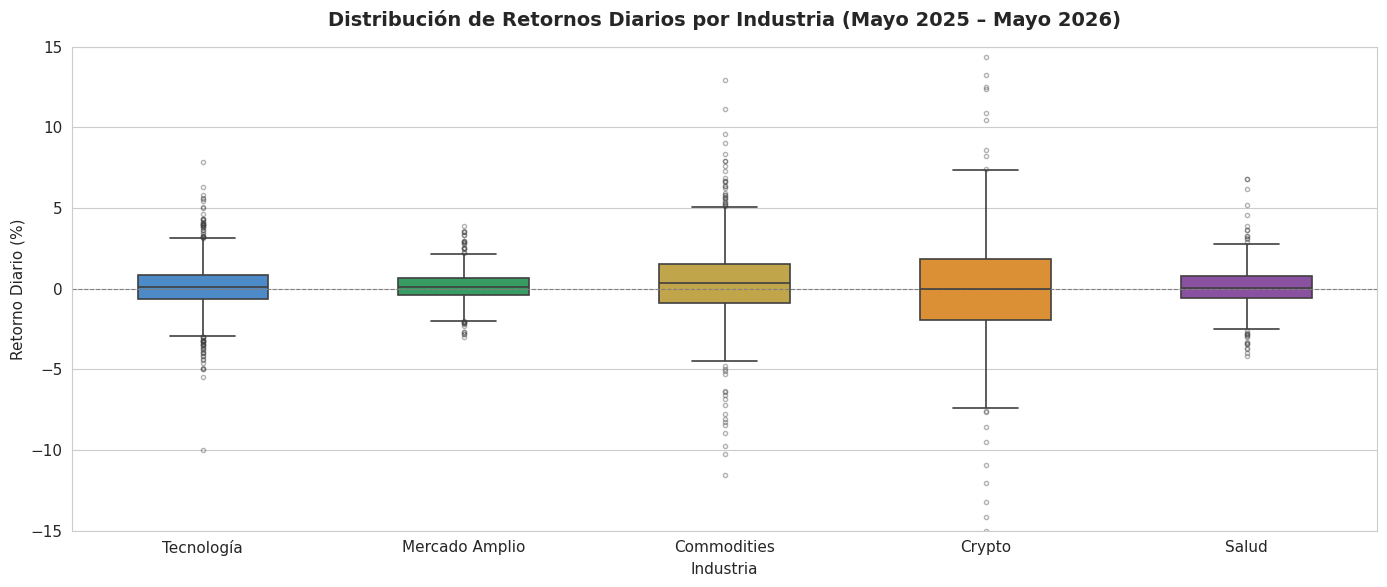

✅ Gráfica 2 guardada


In [33]:
# Preparar datos en formato largo para seaborn
datos_largo = []

for industria, assets in industrias.items():
    for asset in assets:
        if asset in retornos_diarios.columns:
            for valor in retornos_diarios[asset].dropna():
                datos_largo.append({
                    "Industria": industria,
                    "Asset": asset,
                    "Retorno Diario (%)": valor
                })

df_largo = pd.DataFrame(datos_largo)

# Graficar
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_largo,
    x="Industria",
    y="Retorno Diario (%)",
    palette=colores_industria,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

# Línea de referencia en 0
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Títulos y etiquetas
ax.set_title('Distribución de Retornos Diarios por Industria (Mayo 2025 – Mayo 2026)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Industria', fontsize=11)
ax.set_ylabel('Retorno Diario (%)', fontsize=11)

ax.set_ylim(-15, 15)
plt.tight_layout()
plt.savefig('grafica2_boxplot_industrias.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica 2 guardada")

### Justificación — Gráfica 3: Distribución de Volatilidad Ordenada por IQR

Esta gráfica es una mejora directa de la anterior. Se reordenaron
las industrias de mayor a menor volatilidad usando el **IQR como
criterio matemático objetivo**, en lugar de un orden arbitrario.

El reordenamiento convierte la gráfica en una herramienta de decisión
inmediata: el lector no necesita comparar cajas de izquierda a derecha
buscando cuál es más ancha — la respuesta está en el orden visual.

Esta iteración demuestra un principio fundamental de visualización:
una buena gráfica no es solo correcta técnicamente, sino que está
optimizada para comunicar su conclusión con el menor esfuerzo cognitivo
posible.

El orden resultante — Crypto, Commodities, Tecnología, Salud, Mercado
Amplio — establece directamente la escala de riesgo por industria que
el bot utilizará para calibrar el tamaño de cada posición.

📊 Orden por volatilidad (IQR):
  1. Crypto: 3.73%
  2. Commodities: 2.40%
  3. Tecnología: 1.52%
  4. Salud: 1.35%
  5. Mercado Amplio: 1.06%


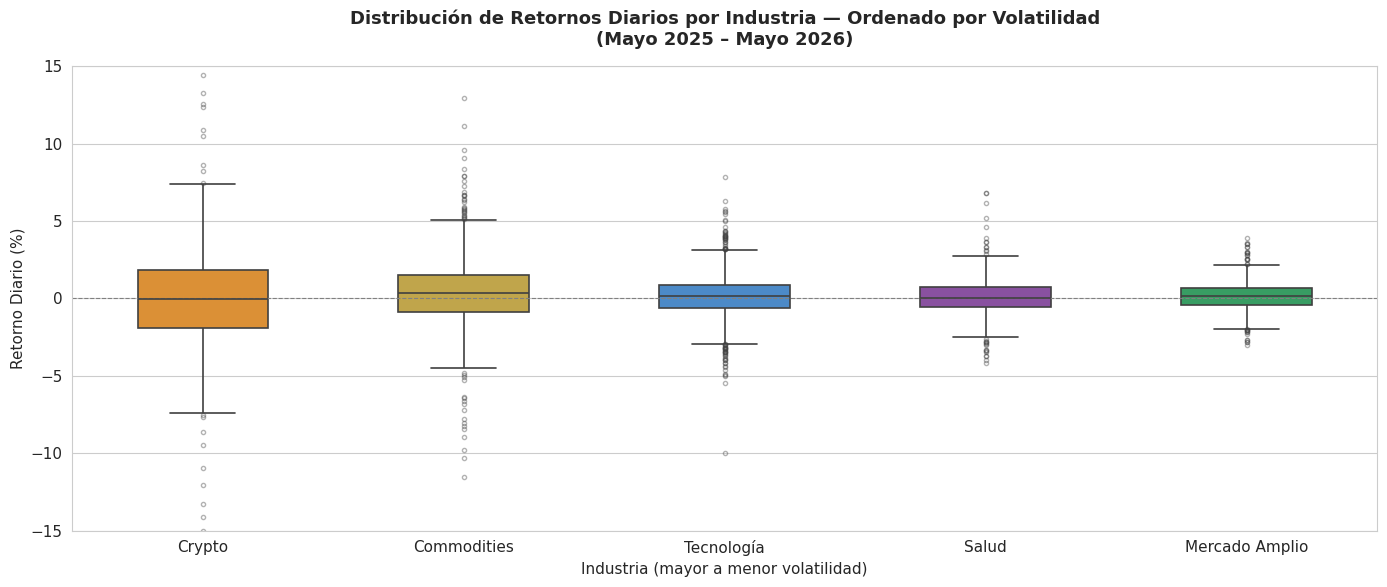

✅ Gráfica 2 actualizada


In [34]:
# Calcular IQR por industria para ordenar de mayor a menor volatilidad
iqr_por_industria = df_largo.groupby("Industria")["Retorno Diario (%)"].apply(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
).sort_values(ascending=False)

orden_industrias = iqr_por_industria.index.tolist()
print("📊 Orden por volatilidad (IQR):")
for i, ind in enumerate(orden_industrias, 1):
    print(f"  {i}. {ind}: {iqr_por_industria[ind]:.2f}%")

# Graficar
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=df_largo,
    x="Industria",
    y="Retorno Diario (%)",
    order=orden_industrias,
    palette=colores_industria,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylim(-15, 15)

ax.set_title('Distribución de Retornos Diarios por Industria — Ordenado por Volatilidad\n(Mayo 2025 – Mayo 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Industria (mayor a menor volatilidad)', fontsize=11)
ax.set_ylabel('Retorno Diario (%)', fontsize=11)

plt.tight_layout()
plt.savefig('grafica2_boxplot_industrias.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica 2 actualizada")

### 5.3 Gráfica 3 — Evolución Temporal Normalizada

### 5.3 Gráfica 3 — Evolución Temporal Normalizada

---
**Justificación del Gráfico:**
* **Tipo de variable representada:** Variable **continua** (precio normalizado) en función de una secuencia temporal cronológica.
* **Propósito del gráfico:** Mostrar la evolución del precio, identificar tendencias de largo plazo, fases de acumulación y puntos de ruptura entre industrias.
* **Principio perceptual aplicado:** Se aplicó el principio de **Continuidad (Gestalt)** mediante el uso de líneas que conectan la secuencia, guiando el ojo naturalmente para percibir la evolución histórica. Además, se aplicó la reducción de **carga cognitiva** al normalizar los precios a base 100, permitiendo una comparación visual directa (manzanas con manzanas) sin saturar al lector con múltiples ejes Y.

Esta visualización responde de manera integral a la pregunta: ***¿Cómo evolucionó el rendimiento de cada industria durante el año?***, permitiendo desglosar los siguientes hitos del mercado apoyados por marcadores y líneas de referencia verticales:

1. **Colapso Crypto (06 de Octubre de 2025):** Marca el **último punto máximo macro** del sector de criptomonedas. A partir de esta fecha exacta, el sector pierde su liderazgo absoluto e inicia una **tendencia bajista prolongada y severa**.
2. **Ascenso Sostenido de Commodities (24 de Noviembre de 2025):** Identifica el punto de inflexión donde esta industria **cruza y supera en precio normalizado** a todos los demás activos del universo analizado, consolidándose como el sector con mejor rendimiento anual (**+62.9%**).
3. **Primera Lateralización de Activos de Riesgo (Nov 2025 – Ene 2026):** Tras el despegue de Commodities, los sectores de **Tecnología, Mercado Amplio y Salud** entran en un estrecho **canal lateral (movimiento en rango)**, denotando un periodo de indecisión y equilibrio temporal de fuerzas en el mercado.
4. **Ruptura y Despegue de Salud (15 de Enero de 2026):** Este periodo de acumulación finaliza a mediados de enero, cuando el sector **Salud logra romper al alza** el rango de lateralización, separándose de Tecnología y Mercado Amplio para asegurar el segundo mejor puesto de rendimiento (**+31.2%**).
5. **Segunda Lateralización (Actualidad - Mayo 2026):** Hacia las últimas semanas del análisis, la volatilidad vuelve a comprimirse. Tecnología, Mercado Amplio y Salud **convergen de nuevo en un rango plano**, señalando una fase de consolidación técnica conjunta en el cierre del periodo.

---

#### Análisis de Divergencia Temporal: El Caso BTC-USD

Al cruzar la lectura macro de esta gráfica con las métricas calculadas en la tabla de variables, se revela una **divergencia técnica vital** para el sistema:

A pesar de que Crypto muestra un desastroso **Retorno Total Anual de -20.1%** (comportamiento estructuralmente bajista evidenciado en la gráfica), el algoritmo del bot lo califica con una tendencia **"Alcista"** al cierre. Esto ocurre porque hacia el final del periodo (mayo de 2026), el precio experimenta un repunte de corto plazo que cruza su **Media Móvil Exponencial de 20 días (EMA 20)**.

Este hallazgo justifica el diseño del sistema: mientras la gráfica (Retorno Total) nos da el contexto **Macro**, indicadores como la EMA nos otorgan sensibilidad **Micro** para detectar impulsos compradores y posibles rebotes técnicos tempranos antes de que cambie la tendencia general.

In [35]:
# Valor final normalizado por industria
print("📈 Valor final normalizado por industria:")
print("(Base 100 = punto de partida Mayo 2025)\n")

for industria, assets in industrias.items():
    assets_disponibles = [a for a in assets if a in precios_limpios.columns]
    precio_industria = precios_limpios[assets_disponibles].mean(axis=1)
    precio_normalizado = (precio_industria / precio_industria.iloc[0]) * 100

    valor_final = precio_normalizado.iloc[-1]
    retorno = valor_final - 100

    signo = "+" if retorno > 0 else ""
    print(f"  {industria}: {valor_final:.1f} ({signo}{retorno:.1f}%)")

📈 Valor final normalizado por industria:
(Base 100 = punto de partida Mayo 2025)

  Tecnología: 126.2 (+26.2%)
  Mercado Amplio: 132.8 (+32.8%)
  Commodities: 162.9 (+62.9%)
  Crypto: 79.9 (-20.1%)
  Salud: 131.1 (+31.1%)


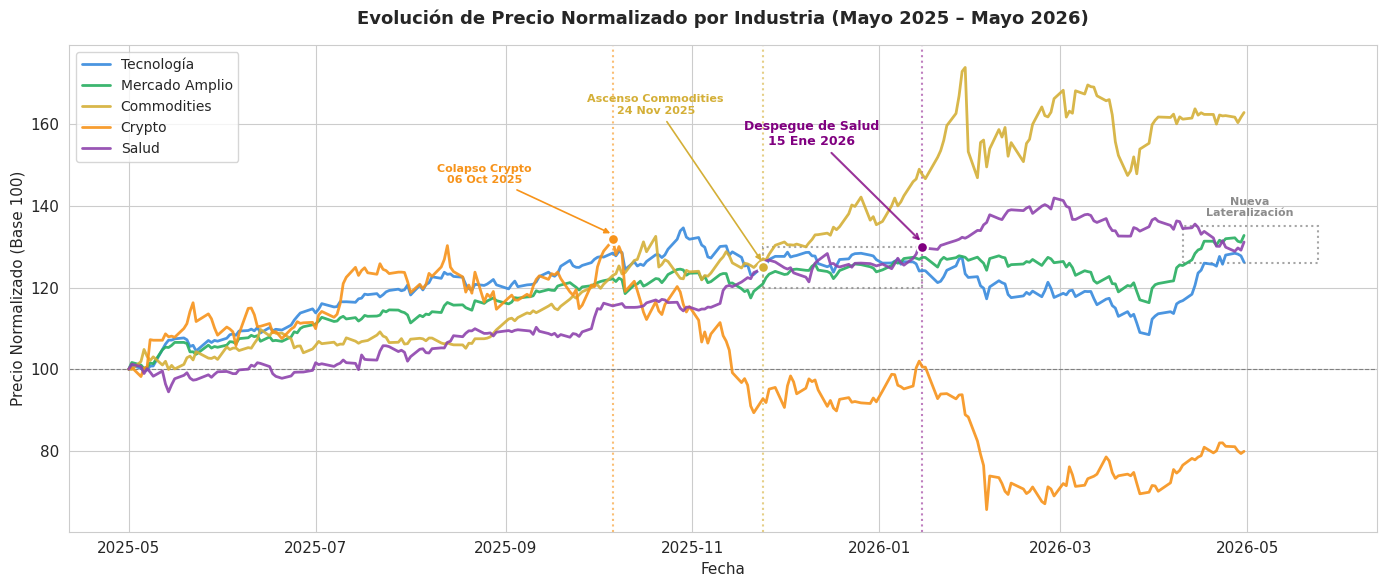

✅ Gráfica 3 guardada con marcadores sólidos pequeños/gruesos y flechas pulidas apuntando directamente.


In [40]:
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Calcular precio promedio por industria (normalizado a 100)
fig, ax = plt.subplots(figsize=(14, 6))

for industria, assets in industrias.items():
    # Filtrar solo los assets disponibles
    assets_disponibles = [a for a in assets if a in precios_limpios.columns]

    # Promedio de precios de la industria
    precio_industria = precios_limpios[assets_disponibles].mean(axis=1)

    # Normalizar a 100 desde el primer día
    precio_normalizado = (precio_industria / precio_industria.iloc[0]) * 100

    ax.plot(
        precio_normalizado.index,
        precio_normalizado.values,
        label=industria,
        color=colores_industria[industria],
        linewidth=2,
        alpha=0.9,
        zorder=3 # Asegurar que las líneas estén sobre el fondo
    )

# Línea de referencia en 100 (punto de partida)
ax.axhline(100, color='gray', linewidth=0.8, linestyle='--', zorder=1)

# Títulos y etiquetas del gráfico
ax.set_title('Evolución de Precio Normalizado por Industria (Mayo 2025 – Mayo 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Precio Normalizado (Base 100)', fontsize=11)
ax.legend(loc='upper left', fontsize=10)

# ==============================================================================
# MARCADORES DE EVENTOS CLAVE (Con Puntos Sólidos Pequeños/Gruesos y Mejores Flechas)
# ==============================================================================

# 1. Colapso Crypto (06 Oct 2025)
fecha_crypto = pd.Timestamp('2025-10-06')
fecha_num_crypto = mdates.date2num(fecha_crypto)
y_crypto = 132
color_crypto = '#F7931A'

# Línea guía vertical (sutil)
ax.axvline(fecha_crypto, color=color_crypto, linewidth=1.5, linestyle=':', alpha=0.6, zorder=0)

# Punto sólido pequeño pero grueso exactamente sobre la línea (zorder alto)
ax.scatter(fecha_num_crypto, y_crypto, color=color_crypto, s=60, edgecolors='white', linewidths=1.5, zorder=5)

# Mejor flecha (ax.annotate con arrowstyle '-|>')
ax.annotate('Colapso Crypto\n06 Oct 2025',
            xy=(fecha_num_crypto, y_crypto + 1),  # Punta directa al punto (xy)
            xytext=(mdates.date2num(pd.Timestamp('2025-08-25')), 145), # Texto en espacio negativo (xytext)
            arrowprops=dict(
                arrowstyle='-|> ', # Flecha sleeker con punta sólida
                connectionstyle='arc3,rad=0', # Recta, apuntando directo
                color=color_crypto,
                linewidth=1.2,
                facecolor=color_crypto # Punta sólida
            ),
            fontsize=8, color=color_crypto, fontweight='bold', ha='center', va='bottom')


# 2. Ascenso Commodities (24 Nov 2025)
fecha_commodities = pd.Timestamp('2025-11-24')
fecha_num_commodities = mdates.date2num(fecha_commodities)
y_commodities = 125
color_commodities = '#D4AF37'

# Línea guía vertical
ax.axvline(fecha_commodities, color=color_commodities, linewidth=1.5, linestyle=':', alpha=0.6, zorder=0)

# Punto sólido
ax.scatter(fecha_num_commodities, y_commodities, color=color_commodities, s=60, edgecolors='white', linewidths=1.5, zorder=5)

# Mejor flecha movida al espacio vacío de la izquierda para no chocar
ax.annotate('Ascenso Commodities\n24 Nov 2025',
            xy=(fecha_num_commodities, y_commodities + 1), # Punta directa al punto
            xytext=(mdates.date2num(pd.Timestamp('2025-10-20')), 162), # Texto alto y a la izquierda
            arrowprops=dict(
                arrowstyle='-|> ',
                connectionstyle='arc3,rad=0',
                color=color_commodities,
                linewidth=1.2,
                facecolor=color_commodities
            ),
            fontsize=8, color=color_commodities, fontweight='bold', ha='center', va='bottom')

# ==============================================================================
# CAJAS DE LATERALIZACIÓN Y BREAKOUTS (Contexto)
# ==============================================================================

# 3. Primera Lateralización (Rango: Nov 2025 - Ene 2026)
inicio_caja1 = pd.Timestamp('2025-11-24')
fin_caja1 = pd.Timestamp('2026-01-15')
inicio_caja1_num = mdates.date2num(inicio_caja1)
ancho_caja1 = mdates.date2num(fin_caja1) - inicio_caja1_num
rect1 = Rectangle((inicio_caja1_num, 120), ancho_caja1, 10,
                  linewidth=1.5, edgecolor='gray', facecolor='none', linestyle=':', alpha=0.7, zorder=2)
ax.add_patch(rect1)

# 4. Despegue de Salud (Ruptura de la caja) con Punto Sólido y Mejor Flecha
fecha_salud = pd.Timestamp('2026-01-15')
fecha_num_salud = mdates.date2num(fecha_salud)
y_salud = 130 # Valor aproximado de ruptura en el box
color_salud = 'purple'

# Línea guía vertical
ax.axvline(fecha_salud, color=color_salud, linewidth=1.5, linestyle=':', alpha=0.5, zorder=0)

# Punto sólido
ax.scatter(fecha_num_salud, y_salud, color=color_salud, s=60, edgecolors='white', linewidths=1.5, zorder=5)

# Mejor flecha movida al espacio vacío de la izquierda e incluyendo fecha
ax.annotate('Despegue de Salud\n15 Ene 2026',
            xy=(fecha_num_salud, y_salud + 1), # Punta directa al punto de ruptura
            xytext=(mdates.date2num(pd.Timestamp('2025-12-10')), 155), # Texto en espacio negativo
            arrowprops=dict(
                arrowstyle='-> ', # Simple arrow, sleeker, head_width/length adjusted by patchA/B if needed. Let's make it direct.
                connectionstyle='arc3,rad=0',
                color=color_salud,
                linewidth=1.5,
                alpha=0.8
                # Nota: facecolor no funciona con style '->', solo líneas directas
            ),
            fontsize=9, color=color_salud, fontweight='bold', ha='center')


# 5. Segunda Lateralización Reciente (Contexto: Rango: Abril 2026 - Mayo 2026)
inicio_caja2 = pd.Timestamp('2026-04-10')
fin_caja2 = pd.Timestamp('2026-05-24')
inicio_caja2_num = mdates.date2num(inicio_caja2)
ancho_caja2 = mdates.date2num(fin_caja2) - inicio_caja2_num
rect2 = Rectangle((inicio_caja2_num, 126), ancho_caja2, 9,
                  linewidth=1.5, edgecolor='gray', facecolor='none', linestyle=':', alpha=0.7, zorder=2)
ax.add_patch(rect2)
ax.text(inicio_caja2_num + (ancho_caja2/2), 137, 'Nueva\nLateralización',
        fontsize=8, color='gray', fontweight='bold', ha='center', va='bottom', alpha=0.9)

# ==============================================================================

plt.tight_layout()
plt.savefig('grafica3_evolucion_industrias_marcadores_pulidos.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica 3 guardada con marcadores sólidos pequeños/gruesos y flechas pulidas apuntando directamente.")

### 5.4 Gráfica 4 — Días con Señal Extrema vs Retorno Total

### 5.4 Gráfica 4 — Relación Riesgo-Rendimiento (Días Extremos vs. Retorno Total)

---
**Justificación del Gráfico:**
* **Tipo de variables representadas:** Correlación entre una variable **discreta** (inestabilidad: número de días con movimiento extremo en el eje X) y una variable **continua** (rentabilidad: Retorno Total en el eje Y).
* **Propósito del gráfico:** Evaluar la relación riesgo-rendimiento de forma individual para identificar qué activos ofrecen el mejor retorno asumiendo la menor volatilidad.
* **Principio perceptual aplicado:** Se utilizaron **atributos preatentivos** (forma y color) mediante una codificación visual múltiple. El color agrupa a los activos por su respectiva industria (principio de **Similitud**), y la forma del marcador (triángulo/círculo) codifica la variable **ordinal** de la tendencia actual. Esto permite decodificar cuatro dimensiones de datos en un solo plano visual sin esfuerzo consciente.

Esta gráfica responde a la pregunta crítica para el diseño del algoritmo: ***¿Qué activos ofrecen el mejor rendimiento asumiendo la menor cantidad de riesgo y volatilidad?*** Revelando hallazgos clave para la ponderación del portafolio:

1. **El Cuadrante Ideal (Alta rentabilidad, baja volatilidad extrema):** Activos como **JNJ** (Salud), **IWM** (Mercado Amplio) y **QQQ** (Tecnología) lograron retornos sólidos (30% - 50%) sufriendo menos de 5 días de volatilidad extrema. Son los candidatos más seguros para el capital base del bot.
2. **Los Ganadores Volátiles:** **USO** y **SLV** dominan el retorno total, pero exigieron soportar más de 40 y 60 días de movimientos extremos, respectivamente. Requieren un *stop-loss* dinámico mucho más holgado.
3. **Eficiencia Tecnológica:** **NVDA** destaca en solitario, ofreciendo el mejor equilibrio del mercado para perfiles de crecimiento (casi 80% de retorno) asumiendo una volatilidad extrema moderada.
4. **El Peor Escenario de Riesgo:** **BTC-USD** presentó más de 40 días extremos solo para entregar un rendimiento fuertemente negativo (-20%), confirmando una ineficiencia severa en su relación riesgo-beneficio durante este periodo anual.

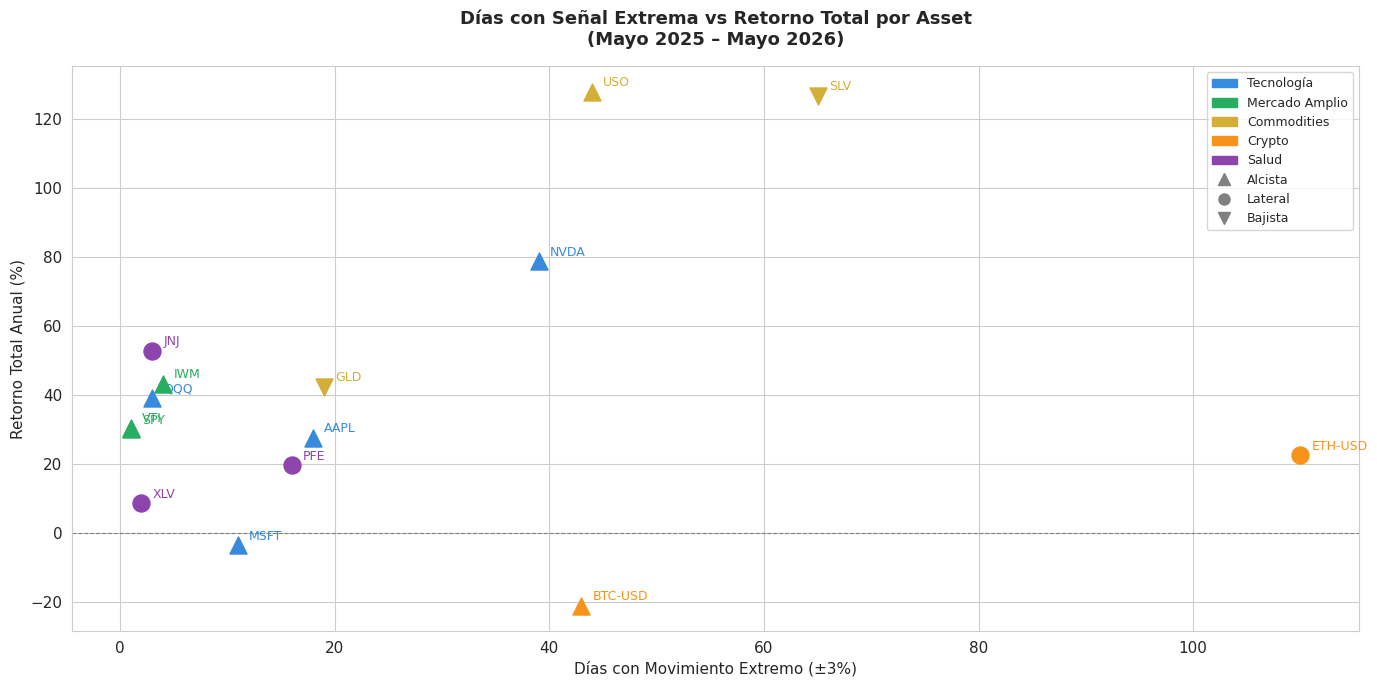

✅ Gráfica 4 guardada


In [37]:
fig, ax = plt.subplots(figsize=(14, 7))

# Marcadores por tendencia
marcadores = {"Alcista": "^", "Lateral": "o", "Bajista": "v"}

for asset in df_variables.index:
    industria = df_variables.loc[asset, "Industria"]
    tendencia_asset = df_variables.loc[asset, "Tendencia"]
    x = df_variables.loc[asset, "Dias_Senal"]
    y = df_variables.loc[asset, "Retorno_Total_%"]
    color = colores_industria[industria]
    marcador = marcadores[tendencia_asset]

    ax.scatter(x, y, color=color, marker=marcador, s=150, zorder=5)
    ax.annotate(
        asset,
        (x, y),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
        color=color
    )

# Línea de referencia en 0
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Leyenda industrias
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

leyenda_industrias = [Patch(color=color, label=ind)
                      for ind, color in colores_industria.items()]

leyenda_tendencias = [
    Line2D([0],[0], marker='^', color='gray', linestyle='None',
           markersize=8, label='Alcista'),
    Line2D([0],[0], marker='o', color='gray', linestyle='None',
           markersize=8, label='Lateral'),
    Line2D([0],[0], marker='v', color='gray', linestyle='None',
           markersize=8, label='Bajista'),
]

ax.legend(handles=leyenda_industrias + leyenda_tendencias,
          loc='upper right', fontsize=9)

ax.set_title('Días con Señal Extrema vs Retorno Total por Asset\n(Mayo 2025 – Mayo 2026)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Días con Movimiento Extremo (±3%)', fontsize=11)
ax.set_ylabel('Retorno Total Anual (%)', fontsize=11)

plt.tight_layout()
plt.savefig('grafica4_senal_vs_retorno.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfica 4 guardada")

## 6. Conclusiones y Resumen


### 6. Conclusiones y Recomendaciones para el Bot de Trading

Basado en el análisis visual y cuantitativo del periodo (Mayo 2025 - Mayo 2026), se establecen las siguientes directrices para la configuración del portafolio del bot:

**Hallazgos Principales por Industria**
* **Commodities (Prioridad Alta):** Dominó el mercado con el mejor rendimiento del periodo (+62.9%) manteniendo una volatilidad controlada (IQR 2.40%).
* **Mercado Amplio (Prioridad Alta):** Entregó un rendimiento sólido (+32.8%) asumiendo la volatilidad más baja de todo el universo analizado (IQR 1.06%).
* **Salud (Prioridad Alta):** Sector refugio con excelente crecimiento (+31.2%) y muy baja volatilidad (IQR 1.35%). Rompió al alza de forma independiente.
* **Tecnología (Prioridad Media):** Rendimiento positivo (+26.2%) y volatilidad moderada (IQR 1.52%), pero su éxito dependió fuertemente de activos individuales.
* **Crypto (Condicional):** Rendimiento macro negativo (-20.1%) combinado con la volatilidad extrema más alta (IQR 3.73%). Exige parámetros de *stop-loss* dinámicos mucho más estrictos.

**Assets Recomendados para el Watchlist**
* **Commodities:** **USO** (+128%) y **GLD** (+42%) mostraron la mejor relación retorno/riesgo del ecosistema.
* **Mercado Amplio:** **IWM** (+43%) demostró ser significativamente más dinámico que SPY y VTI.
* **Salud:** **JNJ** (+53%) mantuvo una consistencia notable, evitando periodos negativos prolongados.
* **Tecnología:** **NVDA** (+79%) se coronó como el activo individual más fuerte y eficiente del sector.
* **Crypto:** **ETH-USD** (+23%) logró desmarcarse de la caída de BTC, mostrándose mucho más estable.

> **Nota Metodológica:** El análisis cubre un horizonte de un año. Para el sector Crypto, se recomienda al algoritmo ampliar la ventana de análisis a 4 años para capturar el impacto macroeconómico de los ciclos de *Halving* de Bitcoin, lo cual podría alterar radicalmente las ponderaciones históricas.

---

### 7. Resumen Teórico: Visualización Efectiva de Datos

**Conceptos Clave de Visualización**
La visualización de datos es el proceso de traducir información cuantitativa en elementos gráficos con el objetivo principal de comunicar conclusiones de forma inmediata. Su correcta aplicación es analítica, no estética, y depende de la naturaleza estadística de la información.

**Tipos de Variables Analizadas:**
1. **Nominales:** Categorías sin orden jerárquico (ej. ticker del activo: *BTC, QQQ*).
2. **Ordinales:** Categorías con orden lógico, pero sin distancia matemática exacta (ej. tendencia técnica: *Bajista, Lateral, Alcista*).
3. **Discretas:** Valores enteros contables (ej. *número de días* con señal extrema).
4. **Continuas:** Valores numéricos que toman cualquier fracción en un rango (ej. *retorno diario porcentual*).

**Principios Perceptuales Aplicados:**
Para diseñar gráficas efectivas, es necesario apelar a la psicología visual humana. En este análisis se aplicaron las **Leyes de Gestalt**, como el principio de *Similitud* (usar el mismo color para identificar a una industria en todas las gráficas) y la *Continuidad* (usar líneas para series de tiempo). Asimismo, se optimizó el **Data-ink ratio** (relación datos-tinta) eliminando bordes innecesarios, fondos saturados y ruido visual para enfocar la atención en el precio.

**Errores Comunes a Evitar:**
En el diseño del panel para el algoritmo de trading se evitaron prácticas engañosas como:
* **Uso de gráficos de pastel (Pie charts):** Ineficientes para comparar el rendimiento de múltiples activos.
* **Escalas Y truncadas o engañosas:** En la Gráfica 1 se inició el eje Y en 0 para evitar distorsionar la magnitud del retorno.
* **Exceso de carga cognitiva (Chartjunk):** Se evitó la saturación de indicadores técnicos sobre la gráfica, utilizando en su lugar marcadores de diseño limpio solo en momentos clave.

In [38]:
# ==============================================================================
# 6.1 WATCHLIST FINAL PROPUESTO PARA EL SISTEMA
# ==============================================================================

watchlist_bot = {
    "Commodities": ["USO", "GLD"],
    "Mercado Amplio": ["IWM"],
    "Salud": ["JNJ"],
    "Tecnología": ["NVDA"],
    "Crypto": ["ETH-USD"]
}

print("✅ Watchlist optimizado y cargado en memoria para el Bot de Trading:\n")

for sector, activos in watchlist_bot.items():
    print(f" 🔹 {sector.ljust(15)} : {', '.join(activos)}")

✅ Watchlist optimizado y cargado en memoria para el Bot de Trading:

 🔹 Commodities     : USO, GLD
 🔹 Mercado Amplio  : IWM
 🔹 Salud           : JNJ
 🔹 Tecnología      : NVDA
 🔹 Crypto          : ETH-USD
